# Additional Analyses for Anhedonia Factor Analysis & Clustering

This notebook extends the primary analysis in `explore_anhedonia_v4_Codex.ipynb` with:
1. **Measurement Quality**: Publication-quality factor loading table, ordinal alpha reliability, polychoric correlation heatmap
2. **Convergent/Discriminant Validity**: Multitrait-Multimethod (MTMM) correlation matrix
3. **Cluster Visualizations**: Radar plot, pairplot, KDE overlap, alluvial diagram
4. **External Clinical Validation**: Cluster comparisons on measures NOT used in factor analysis
5. **Robustness**: SHAPS-only vs multi-scale comparison, bootstrap stability, permutation test

All data is loaded from pre-computed outputs of the primary notebook and the original imputed scale files.

In [1]:
# =============================================================================
# IMPORTS
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize_scalar
from scipy.stats import multivariate_normal, spearmanr, mannwhitneyu
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

print("All imports loaded successfully.")

All imports loaded successfully.


## 0. Data Loading & Reconstruction

We load the raw imputed item-level data and the pre-computed cluster assignments from the primary notebook. We then reconstruct the polychoric correlation matrix, factor loadings, and factor scores using the same custom functions from the primary notebook.

In [2]:
# =============================================================================
# 0a. LOAD RAW ITEM-LEVEL DATA (same pipeline as primary notebook)
# =============================================================================
base = '/Users/proghani/Documents/personal/local_thesis_proj/TCP_thesis_project/phenotype/imputed/'

# Load imputed item-level data
shaps_items = pd.read_csv(f'{base}imputed_shaps01.csv')
teps_items  = pd.read_csv(f'{base}imputed_teps01.csv')
dass_items  = pd.read_csv(f'{base}imputed_dass01.csv')

# --- Reverse TEPS so higher = more anhedonia (consistent with SHAPS/DASS) ---
all_teps_items = [f'teps{i}' for i in range(1, 19)]
for item in all_teps_items:
    if item in teps_items.columns:
        teps_items[item] = 7 - teps_items[item]

# --- Define item groupings ---
shaps_items_list = [f'shaps{i}' for i in range(1, 15)]           # 14 items
teps_anticipatory  = ['teps1','teps4','teps6','teps8','teps10','teps11','teps15','teps16','teps18']   # 9 items
teps_consummatory  = ['teps2','teps3','teps5','teps7','teps9','teps12','teps13','teps14','teps17']    # 9 items
dass_anticipatory  = ['dass_p1_10','dass_p2_10','dass_p1_16']    # 3 items
dass_consummatory  = ['dass_p1_3','dass_p2_3']                   # 2 items

# Master list of all 37 anhedonia items
anhedonia_items = shaps_items_list + teps_anticipatory + teps_consummatory + dass_anticipatory + dass_consummatory
print(f"Total anhedonia items: {len(anhedonia_items)}")

# --- Find shared subjects across all 3 scales ---
shared = set(shaps_items['subjectkey']) & set(teps_items['subjectkey']) & set(dass_items['subjectkey'])
print(f"Shared subjects across SHAPS, TEPS, DASS: {len(shared)}")

# --- Build merged item-level dataframe ---
factor_data = shaps_items[shaps_items['subjectkey'].isin(shared)][['subjectkey'] + shaps_items_list].copy()
teps_sub = teps_items[teps_items['subjectkey'].isin(shared)][['subjectkey'] + teps_anticipatory + teps_consummatory].copy()
dass_sub = dass_items[dass_items['subjectkey'].isin(shared)][['subjectkey'] + dass_anticipatory + dass_consummatory].copy()
factor_data = factor_data.merge(teps_sub, on='subjectkey').merge(dass_sub, on='subjectkey')

# X = item-level analysis matrix (no subjectkey column)
X = factor_data[anhedonia_items]
print(f"Analysis matrix X: {X.shape[0]} subjects × {X.shape[1]} items")

Total anhedonia items: 37
Shared subjects across SHAPS, TEPS, DASS: 219
Analysis matrix X: 219 subjects × 37 items


In [10]:
# =============================================================================
# 0b. LOAD PRE-COMPUTED CLUSTER ASSIGNMENTS from primary notebook
# =============================================================================

# Polychoric GMM clusters (from explore_anhedonia_v4_Codex.ipynb)
# Using the locked-down original CSV to avoid polychoric recomputation drift
poly_clusters = pd.read_csv('NEW_anhedonia_polychoric_gmm_clusters.csv')
print(f"Polychoric GMM clusters: {poly_clusters.shape[0]} subjects")
print(f"  Cluster 0 (High anhedonia): n={sum(poly_clusters['gmm_cluster']==0)}")
print(f"  Cluster 1 (Low anhedonia):  n={sum(poly_clusters['gmm_cluster']==1)}")

# SHAPS-only GMM clusters (from explore_anehdonia_SHAPS.ipynb)
shaps_clusters = pd.read_csv('shaps_teps_anhedonia_clusters.csv')
print(f"\nSHAPS GMM clusters: {shaps_clusters.shape[0]} subjects")
print(f"  Cluster 0 (Low):  n={sum(shaps_clusters['cluster']==0)}")
print(f"  Cluster 1 (High): n={sum(shaps_clusters['cluster']==1)}")

# SHAPS cutoff groups (SHAPS >= 3)
shaps_cutoff = pd.read_csv('shaps_cutoff_3_groups.csv')
print(f"\nSHAPS cutoff (>=3): {shaps_cutoff.shape[0]} subjects")
print(f"  Group 0 (SHAPS<3):  n={sum(shaps_cutoff['group']==0)}")
print(f"  Group 1 (SHAPS>=3): n={sum(shaps_cutoff['group']==1)}")

Polychoric GMM clusters: 219 subjects
  Cluster 0 (High anhedonia): n=74
  Cluster 1 (Low anhedonia):  n=145

SHAPS GMM clusters: 219 subjects
  Cluster 0 (Low):  n=181
  Cluster 1 (High): n=38

SHAPS cutoff (>=3): 219 subjects
  Group 0 (SHAPS<3):  n=180
  Group 1 (SHAPS>=3): n=39


In [3]:
# =============================================================================
# 0c. LOAD POLYCHORIC CORRELATION MATRIX & FACTOR LOADINGS
#     (Pre-computed in explore_anhedonia_v4_Codex.ipynb — run that notebook's
#      export cell first if these files don't exist yet)
# =============================================================================
import os

r_path = 'polychoric_R_matrix.csv'
l_path = 'polychoric_factor_loadings.csv'

if os.path.exists(r_path) and os.path.exists(l_path):
    R_poly = pd.read_csv(r_path, index_col=0)
    loadings_poly = pd.read_csv(l_path, index_col=0)
    print(f"Loaded polychoric R: {R_poly.shape}")
    print(f"Loaded factor loadings: {loadings_poly.shape}")
    print(f"Factors: {list(loadings_poly.columns)}")
else:
    raise FileNotFoundError(
        f"Missing {r_path} or {l_path}.\n"
        "Run the export cell in explore_anhedonia_v4_Codex.ipynb first "
        "(the cell after factor score computation that saves these CSVs)."
    )

Loaded polychoric R: (37, 37)
Loaded factor loadings: (37, 4)
Factors: ['Factor1', 'Factor2', 'Factor3', 'Factor4']


In [4]:
# =============================================================================
# 0d. COMPUTE FACTOR SCORES (regression method) & SCALE TOTALS
# =============================================================================

def compute_factor_scores(data_matrix, loadings, correlation_matrix):
    """Compute factor scores using regression method (same as primary notebook)."""
    R_inv = np.linalg.pinv(correlation_matrix.values)
    L = loadings.values
    factor_score_coeff = R_inv @ L @ np.linalg.pinv(L.T @ R_inv @ L)
    data_std = (data_matrix - data_matrix.mean()) / data_matrix.std()
    return data_std.values @ factor_score_coeff

factor_scores = compute_factor_scores(X, loadings_poly, R_poly)
factor_scores_df = pd.DataFrame(
    factor_scores,
    columns=['PolyFactor1', 'PolyFactor2', 'PolyFactor3', 'PolyFactor4'],
    index=X.index
)
factor_scores_df['subjectkey'] = factor_data['subjectkey'].values

# Merge in cluster assignments from the pre-computed file
factor_scores_df = factor_scores_df.merge(
    poly_clusters[['subjectkey', 'gmm_cluster', 'max_probability']],
    on='subjectkey'
)

# Compute scale totals for downstream use
fd_indexed = factor_data.set_index('subjectkey')
skeys = factor_scores_df['subjectkey'].values

factor_scores_df['SHAPS_total'] = fd_indexed.loc[skeys, shaps_items_list].sum(axis=1).values
factor_scores_df['TEPS_ant_total'] = fd_indexed.loc[skeys, teps_anticipatory].mean(axis=1).values
factor_scores_df['TEPS_con_total'] = fd_indexed.loc[skeys, teps_consummatory].mean(axis=1).values
factor_scores_df['DASS_anh_total'] = fd_indexed.loc[skeys, dass_anticipatory + dass_consummatory].mean(axis=1).values

# Create readable cluster labels
factor_scores_df['cluster_label'] = factor_scores_df['gmm_cluster'].map(
    {0: 'High Anhedonia', 1: 'Low Anhedonia'}
)

print(f"Factor scores + clusters: {factor_scores_df.shape}")
print(f"\nCluster summary:")
print(factor_scores_df.groupby('cluster_label')[['PolyFactor1','SHAPS_total','DASS_anh_total']].mean().round(3))

NameError: name 'poly_clusters' is not defined

---
## 1a. Publication-Quality Factor Loading Table

Standard EFA reporting table: items in rows, factors in columns, loadings > 0.30 highlighted, communalities (h²) in a final column. Loadings < 0.20 are suppressed for readability.

In [5]:
# =============================================================================
# 1a. PUBLICATION-QUALITY FACTOR LOADING TABLE
# =============================================================================

# Compute communalities (h² = sum of squared loadings per item)
loadings_table = loadings_poly.copy()
loadings_table['h²'] = (loadings_poly ** 2).sum(axis=1)

# Create human-readable item labels
item_labels = {}
for item in shaps_items_list:
    item_labels[item] = f"{item} (SHAPS)"
for item in teps_anticipatory:
    item_labels[item] = f"{item} (TEPS-Ant)"
for item in teps_consummatory:
    item_labels[item] = f"{item} (TEPS-Con)"
for item in dass_anticipatory:
    item_labels[item] = f"{item} (DASS-Anh)"
for item in dass_consummatory:
    item_labels[item] = f"{item} (DASS-Anh)"

loadings_display = loadings_table.copy()
loadings_display.index = [item_labels.get(i, i) for i in loadings_display.index]

# Sort items by their primary factor (highest absolute loading)
loadings_display['primary_factor'] = loadings_poly.abs().idxmax(axis=1).values
loadings_display['max_loading'] = loadings_poly.abs().max(axis=1).values
loadings_display = loadings_display.sort_values(['primary_factor', 'max_loading'], ascending=[True, False])
loadings_display = loadings_display.drop(columns=['primary_factor', 'max_loading'])

# --- Styled display: suppress |loading| < 0.20, bold |loading| >= 0.30 ---
def style_loading(val, col_name):
    """Format loadings for publication table."""
    if col_name == 'h²':
        return f"{val:.3f}"
    if abs(val) < 0.20:
        return "—"
    elif abs(val) >= 0.30:
        return f"**{val:.3f}**"
    else:
        return f"{val:.3f}"

# Print the table
print("=" * 85)
print("TABLE 1: Polychoric EFA Factor Loadings (PAF + Varimax, 4 Factors)")
print("=" * 85)
print(f"{'Item':<25} {'Factor1':>9} {'Factor2':>9} {'Factor3':>9} {'Factor4':>9} {'h²':>8}")
print("-" * 85)
for idx, row in loadings_display.iterrows():
    vals = []
    for col in ['Factor1', 'Factor2', 'Factor3', 'Factor4']:
        v = row[col]
        if abs(v) < 0.20:
            vals.append(f"{'—':>9}")
        elif abs(v) >= 0.30:
            vals.append(f"  {v:+.3f}*")
        else:
            vals.append(f"  {v:+.3f} ")
    print(f"{idx:<25} {''.join(vals)}  {row['h²']:.3f}")

# Variance explained per factor
var_explained = (loadings_poly ** 2).sum(axis=0) / len(anhedonia_items)
print("-" * 85)
print(f"{'Variance explained':<25}", end="")
for v in var_explained:
    print(f"  {v:.3f}  ", end="")
print()
print(f"{'Cumulative':<25}", end="")
cum = 0
for v in var_explained:
    cum += v
    print(f"  {cum:.3f}  ", end="")
print()
print("=" * 85)
print(f"\nN = {X.shape[0]}. Extraction: PAF. Rotation: Varimax.")
print("Loadings ≥ |0.30| marked with *. Loadings < |0.20| suppressed (—).")
print(f"h² = communality (sum of squared loadings).")

TABLE 1: Polychoric EFA Factor Loadings (PAF + Varimax, 4 Factors)
Item                        Factor1   Factor2   Factor3   Factor4       h²
-------------------------------------------------------------------------------------
dass_p1_16 (DASS-Anh)       +0.936*        —        —  +0.251   0.941
dass_p1_10 (DASS-Anh)       +0.925*        —        —        —  0.871
dass_p2_3 (DASS-Anh)        +0.874*        —        —  +0.256   0.842
dass_p2_10 (DASS-Anh)       +0.873*        —        —  +0.211   0.826
dass_p1_3 (DASS-Anh)        +0.854*        —        —        —  0.779
shaps3 (SHAPS)              +0.761*  +0.205         —  +0.438*  0.813
teps4 (TEPS-Ant)            +0.748*  +0.349*        —        —  0.735
shaps4 (SHAPS)              +0.648*        —  +0.243   +0.469*  0.702
shaps5 (SHAPS)              +0.603*  +0.444*        —  +0.388*  0.748
teps13 (TEPS-Con)           -0.397*        —  -0.223   -0.223   0.261
teps17 (TEPS-Con)                 —  +0.702*        —        —  0.519
te

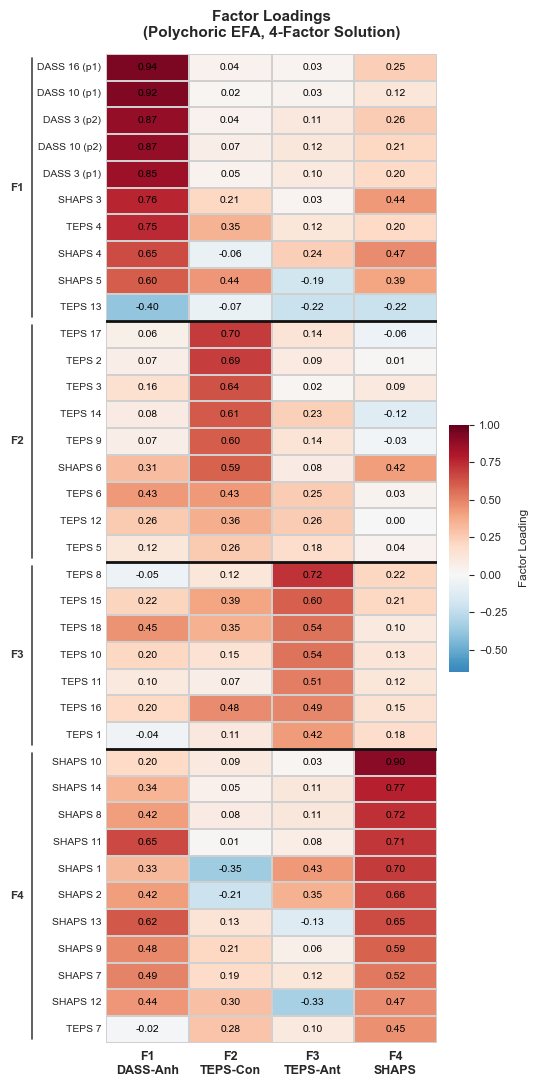

In [13]:
# =============================================================================
# PUBLICATION-QUALITY FACTOR LOADINGS HEATMAP
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# --- Clean item labels ---
def clean_label(name):
    if name.startswith('dass'):
        part, num = name.split('_')[1], name.split('_')[2]   # dass_p1_10 -> p1, 10
        return f'DASS {num} ({part})'
    if name.startswith('shaps'): return f'SHAPS {name.replace("shaps", "")}'
    if name.startswith('teps'):  return f'TEPS {name.replace("teps", "")}'
    return name

y_labels = [clean_label(i) for i in item_order]

# --- Annotation matrix: suppress |loading| < 0.30 ---
loadings_disp = loadings_poly.loc[item_order].copy()
annot = loadings_disp.map(
    lambda x: f'{x:.2f}' if abs(x) >= 0.0 else ''
)

# --- Plot ---
fig, ax = plt.subplots(figsize=(5.5, 11))

hm = sns.heatmap(
    loadings_disp,
    cmap='RdBu_r',
    center=0,
    vmin=-0.65, vmax=1.0,
    annot=annot,
    fmt='',
    annot_kws={'size': 7.5, 'weight': 'normal', 'color': 'black'},
    linewidths=0.35,
    linecolor='#d0d0d0',
    yticklabels=y_labels,
    xticklabels=False,
    cbar_kws={
        'shrink': 0.25,
        'aspect': 12,
        'pad': 0.03,
    },
    ax=ax,
    square=False,
)

# --- Factor boundary lines ---
for b in [10, 19, 26]:
    ax.axhline(y=b, color='#111111', linewidth=2.0)

# --- X-axis factor labels ---
ax.set_xticks([0.5, 1.5, 2.5, 3.5])
ax.set_xticklabels(['F1\nDASS-Anh', 'F2\nTEPS-Con', 'F3\nTEPS-Ant', 'F4\nSHAPS'],
                   fontsize=9, ha='center', fontweight='bold')
ax.tick_params(axis='x', length=0, pad=6)

# --- Y-axis formatting ---
ax.set_yticklabels(y_labels, fontsize=7.5, rotation=0)
ax.tick_params(axis='y', length=0)

# --- Factor group labels on the LEFT side (avoids colorbar overlap) ---
factor_spans = [(0, 10, 'F1'), (10, 19, 'F2'), (19, 26, 'F3'), (26, 37, 'F4')]
factor_colors = ['#555555', '#555555', '#555555', '#555555']
for (start, end, label), color in zip(factor_spans, factor_colors):
    mid = (start + end) / 2
    ax.plot([-0.9, -0.9], [start + 0.15, end - 0.15],
            color='#444444', linewidth=1.2,
            transform=ax.transData, clip_on=False)
    ax.text(-1.0, mid, label, fontsize=8.5, ha='right', va='center',
            fontweight='bold', color='#333333',
            transform=ax.transData, clip_on=False)

# --- Colorbar formatting ---
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)
cbar.set_label('Factor Loading', fontsize=8.5, labelpad=8)
cbar.set_ticks([-0.5, -0.25, 0, 0.25, 0.5, 0.75, 1.0])

# --- Title ---
ax.set_title('Factor Loadings\n(Polychoric EFA, 4-Factor Solution)',
             fontsize=11, fontweight='bold', pad=12)

# --- Suppression note ---
# fig.text(0.01, -0.01, 'Note: Loadings < 0.30 suppressed for clarity.',
#          fontsize=7.5, color='#555555', style='italic')

plt.tight_layout()
plt.savefig('factor_loadings_publication.png', dpi=600, bbox_inches='tight')
plt.show()


---
## 1b. Ordinal Alpha (Polychoric-Based Reliability)

Standard Cronbach's alpha underestimates reliability for ordinal data. Ordinal alpha uses the polychoric correlation matrix instead of Pearson correlations, providing a more accurate estimate for Likert-scale items (Gadermann, Guhn, & Zumbo, 2012).

In [7]:
# =============================================================================
# 1b. ORDINAL ALPHA (POLYCHORIC-BASED RELIABILITY)
# =============================================================================

def ordinal_alpha(R_sub):
    """
    Compute ordinal alpha from a polychoric correlation sub-matrix.
    Formula: alpha = (p / (p-1)) * (1 - p / sum(R))
    where p = number of items and sum(R) = sum of all elements in R.
    Reference: Gadermann, Guhn, & Zumbo (2012).
    """
    p = R_sub.shape[0]
    if p < 2:
        return np.nan
    total_sum = R_sub.values.sum()  # sum of all elements (including diagonal)
    return (p / (p - 1)) * (1 - p / total_sum)

def cronbach_alpha(data_sub):
    """Standard Cronbach's alpha (Pearson-based) for comparison."""
    k = data_sub.shape[1]
    if k < 2:
        return np.nan
    item_vars = data_sub.var(axis=0, ddof=1)
    total_var = data_sub.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_vars.sum() / total_var)

# Define scale groupings for reliability analysis
scale_groups = {
    'SHAPS (14 items)':           shaps_items_list,
    'TEPS Anticipatory (9 items)': teps_anticipatory,
    'TEPS Consummatory (9 items)': teps_consummatory,
    'DASS Anhedonia (5 items)':    dass_anticipatory + dass_consummatory,
    'All 37 Items':                anhedonia_items,
}

# Also compute reliability for items loading on each factor (|loading| >= 0.30)
for f in ['Factor1', 'Factor2', 'Factor3', 'Factor4']:
    loading_items = loadings_poly.index[loadings_poly[f].abs() >= 0.30].tolist()
    if len(loading_items) >= 2:
        scale_groups[f"{f} items (|λ|≥0.30)"] = loading_items

print("=" * 75)
print("TABLE 2: Internal Consistency — Ordinal Alpha vs Cronbach's Alpha")
print("=" * 75)
print(f"{'Scale':<32} {'k':>4} {'α_ordinal':>12} {'α_Cronbach':>12} {'Δ':>8}")
print("-" * 75)

for name, items in scale_groups.items():
    R_sub = R_poly.loc[items, items]
    data_sub = X[items]
    
    alpha_ord = ordinal_alpha(R_sub)
    alpha_cr = cronbach_alpha(data_sub)
    delta = alpha_ord - alpha_cr if not np.isnan(alpha_ord) else np.nan
    
    print(f"{name:<32} {len(items):>4} {alpha_ord:>12.3f} {alpha_cr:>12.3f} {delta:>+8.3f}")

print("-" * 75)
print("Note: Ordinal alpha uses polychoric correlations (appropriate for ordinal data).")
print("Δ = α_ordinal − α_Cronbach. Positive Δ indicates Cronbach underestimates reliability.")

TABLE 2: Internal Consistency — Ordinal Alpha vs Cronbach's Alpha
Scale                               k    α_ordinal   α_Cronbach        Δ
---------------------------------------------------------------------------
SHAPS (14 items)                   14        0.955        0.863   +0.092
TEPS Anticipatory (9 items)         9        0.839        0.790   +0.048
TEPS Consummatory (9 items)         9        0.711        0.604   +0.107
DASS Anhedonia (5 items)            5        0.972        0.945   +0.027
All 37 Items                       37        0.941        0.838   +0.103
Factor1 items (|λ|≥0.30)           22        0.952        0.819   +0.134
Factor2 items (|λ|≥0.30)           14        0.878        0.817   +0.061
Factor3 items (|λ|≥0.30)           10        0.814        0.739   +0.075
Factor4 items (|λ|≥0.30)           15        0.950        0.696   +0.254
---------------------------------------------------------------------------
Note: Ordinal alpha uses polychoric correlations (ap

---
## 1c. Polychoric Correlation Heatmap (37 × 37)

Items ordered by their primary factor loading to reveal the block-diagonal structure that justifies the 4-factor solution.

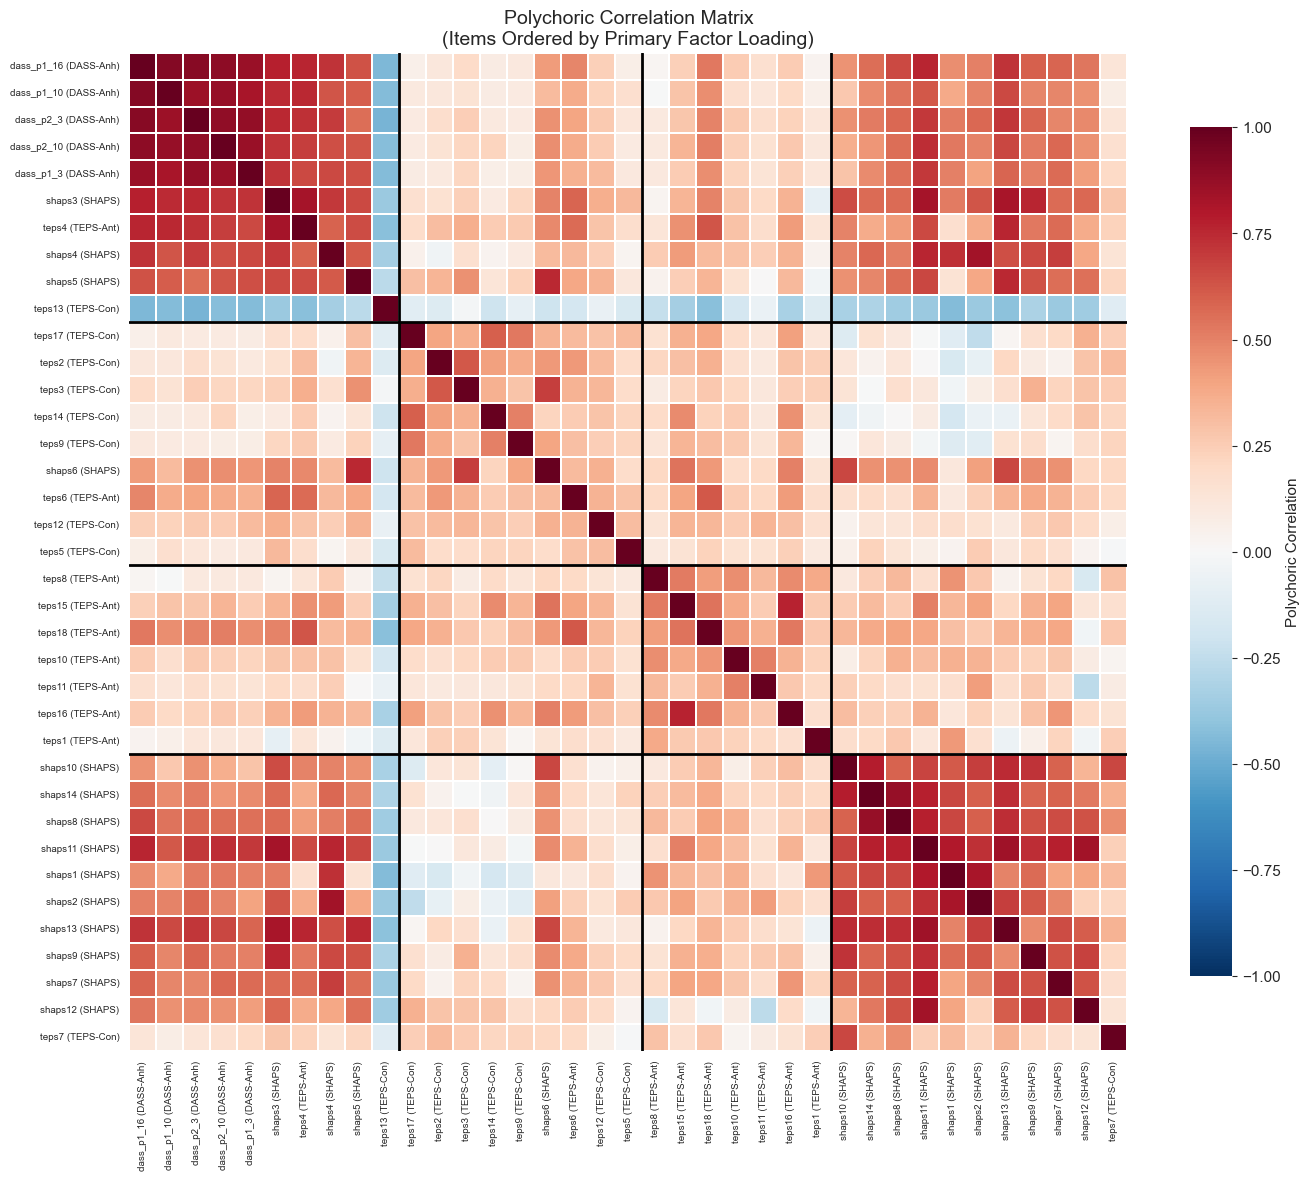

Block-diagonal structure visible: items within the same factor correlate more strongly.


In [8]:
# =============================================================================
# 1c. POLYCHORIC CORRELATION HEATMAP ORDERED BY FACTOR
# =============================================================================

# Order items by their primary factor, then by loading magnitude within each factor
item_order = []
for f in ['Factor1', 'Factor2', 'Factor3', 'Factor4']:
    # Items whose highest absolute loading is on this factor
    primary = loadings_poly.loc[loadings_poly.abs().idxmax(axis=1) == f]
    # Sort descending by the absolute loading on this factor
    primary_sorted = primary.reindex(primary[f].abs().sort_values(ascending=False).index)
    item_order.extend(primary_sorted.index.tolist())

# Reorder the polychoric matrix
R_ordered = R_poly.loc[item_order, item_order]

# Create labels showing scale origin
ordered_labels = [item_labels.get(i, i) for i in item_order]

# Plot
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.zeros_like(R_ordered, dtype=bool)

sns.heatmap(
    R_ordered, 
    mask=mask,
    cmap='RdBu_r', 
    center=0, 
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.1,
    xticklabels=ordered_labels,
    yticklabels=ordered_labels,
    cbar_kws={'label': 'Polychoric Correlation', 'shrink': 0.8},
    ax=ax
)

# Add factor boundary lines
boundaries = []
cum = 0
for f in ['Factor1', 'Factor2', 'Factor3', 'Factor4']:
    n_items = sum(loadings_poly.abs().idxmax(axis=1) == f)
    cum += n_items
    boundaries.append(cum)

for b in boundaries[:-1]:
    ax.axhline(y=b, color='black', linewidth=2)
    ax.axvline(x=b, color='black', linewidth=2)

ax.set_title('Polychoric Correlation Matrix\n(Items Ordered by Primary Factor Loading)', fontsize=14)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig('polychoric_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Block-diagonal structure visible: items within the same factor correlate more strongly.")

---
## 3a. Radar/Spider Plot of Cluster Profiles

Shows the standardized mean on each factor score for each cluster. Reveals whether the high-anhedonia cluster is uniformly elevated or shows a dimension-specific pattern.

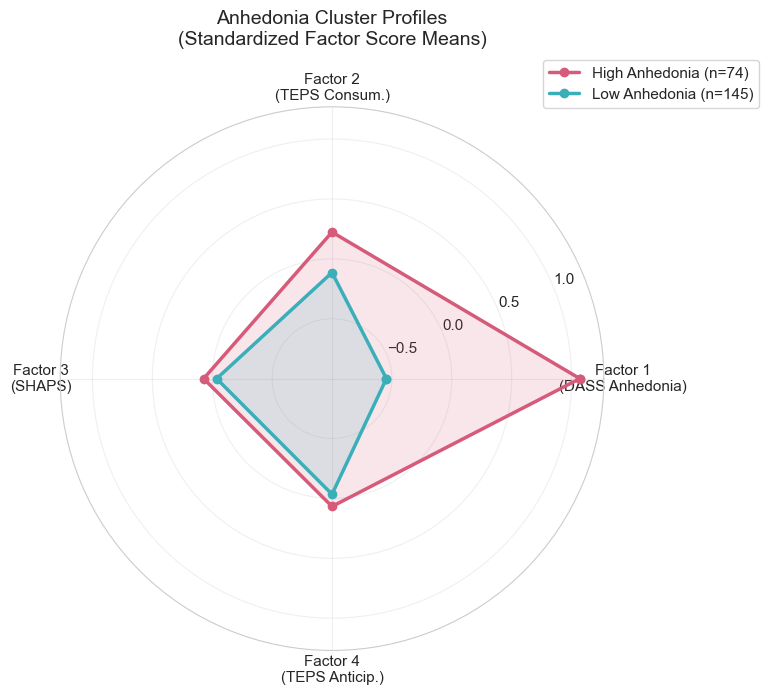


Cluster factor score means:
                PolyFactor1  PolyFactor2  PolyFactor3  PolyFactor4
cluster_label                                                     
High Anhedonia        1.069        0.224        0.072        0.067
Low Anhedonia        -0.546       -0.114       -0.037       -0.034


In [ ]:
# =============================================================================
# 3a. RADAR/SPIDER PLOT OF CLUSTER PROFILES
# =============================================================================

factor_cols = ['PolyFactor1', 'PolyFactor2', 'PolyFactor3', 'PolyFactor4']
factor_names = ['Factor 1\n(DASS Anhedonia)', 'Factor 2\n(TEPS Consum.)', 
                'Factor 3\n(SHAPS)', 'Factor 4\n(TEPS Anticip.)']

# Compute cluster means
cluster_means = factor_scores_df.groupby('cluster_label')[factor_cols].mean()

# Set up radar chart
angles = np.linspace(0, 2 * np.pi, len(factor_cols), endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

colors = {
    'High Anhedonia': "#D65A7A",
    'Low Anhedonia': "#3AAFB9"
}


for label, row in cluster_means.iterrows():
    values = row.tolist()
    values += values[:1]  # close the polygon
    n = sum(factor_scores_df['cluster_label'] == label)
    ax.plot(angles, values, 'o-', linewidth=2.5, label=f'{label} (n={n})', color=colors[label])
    ax.fill(angles, values, alpha=0.15, color=colors[label])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(factor_names, fontsize=11)
ax.set_title('Anhedonia Cluster Profiles\n(Standardized Factor Score Means)', fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax.set_ylim(min(-1.0, cluster_means.min().min() - 0.2), max(1.0, cluster_means.max().max() + 0.2))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cluster_radar_profile.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the means table
print("\nCluster factor score means:")
print(cluster_means.round(3).to_string())

---
## 3b. Pairplot of Factor Scores by Cluster

4×4 scatter matrix showing pairwise relationships between all factor scores, colored by cluster assignment. Reveals which factor dimensions drive the separation.

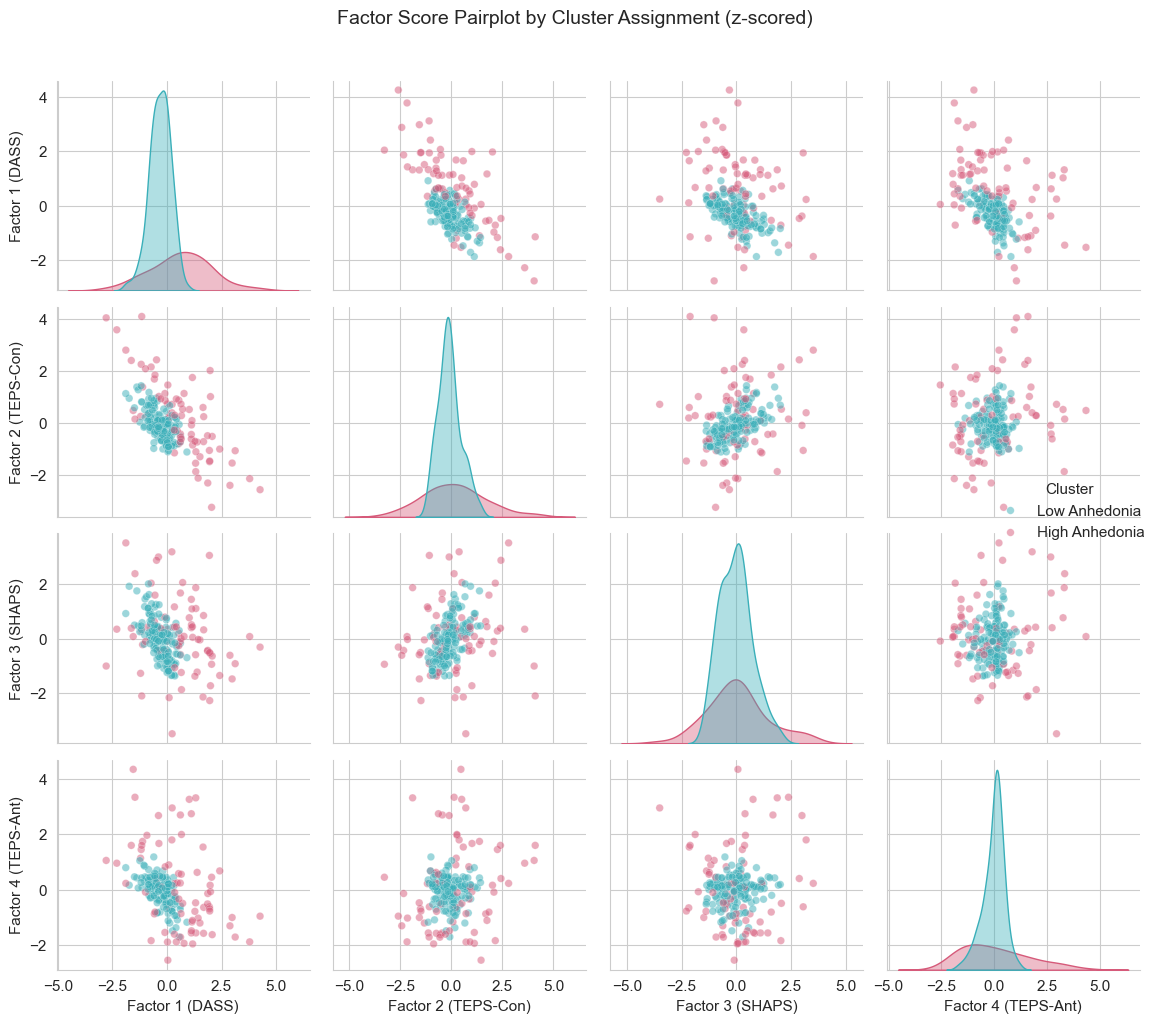

Factor scores z-standardized for comparable axes.
Factor 1 (DASS severity) shows the clearest cluster separation along the diagonal KDEs.


In [20]:
# =============================================================================
# 3b. PAIRPLOT OF FACTOR SCORES BY CLUSTER
# =============================================================================

# Standardize factor scores (z-scores) so axes are comparable across factors
factor_cols = ['PolyFactor1', 'PolyFactor2', 'PolyFactor3', 'PolyFactor4']
plot_df = factor_scores_df[factor_cols + ['cluster_label']].copy()

for col in factor_cols:
    plot_df[col] = (plot_df[col] - plot_df[col].mean()) / plot_df[col].std()

plot_df.columns = ['Factor 1 (DASS)', 'Factor 2 (TEPS-Con)', 
                   'Factor 3 (SHAPS)', 'Factor 4 (TEPS-Ant)', 'Cluster']

g = sns.pairplot(
    plot_df, 
    hue='Cluster',
    palette={'High Anhedonia': "#D65A7A", 'Low Anhedonia': "#3AAFB9"},
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 30, 'edgecolor': 'white', 'linewidth': 0.3},
    diag_kws={'fill': True, 'alpha': 0.4},
    corner=False
)
g.figure.suptitle('Factor Score Pairplot by Cluster Assignment (z-scored)', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('factor_pairplot_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print("Factor scores z-standardized for comparable axes."
      "\nFactor 1 (DASS severity) shows the clearest cluster separation along the diagonal KDEs.")

---
## 3c. KDE Distribution Overlap Plots

Overlaid kernel density estimates for each scale total, comparing High vs Low anhedonia clusters. Shows where the clusters separate most cleanly on each original scale.

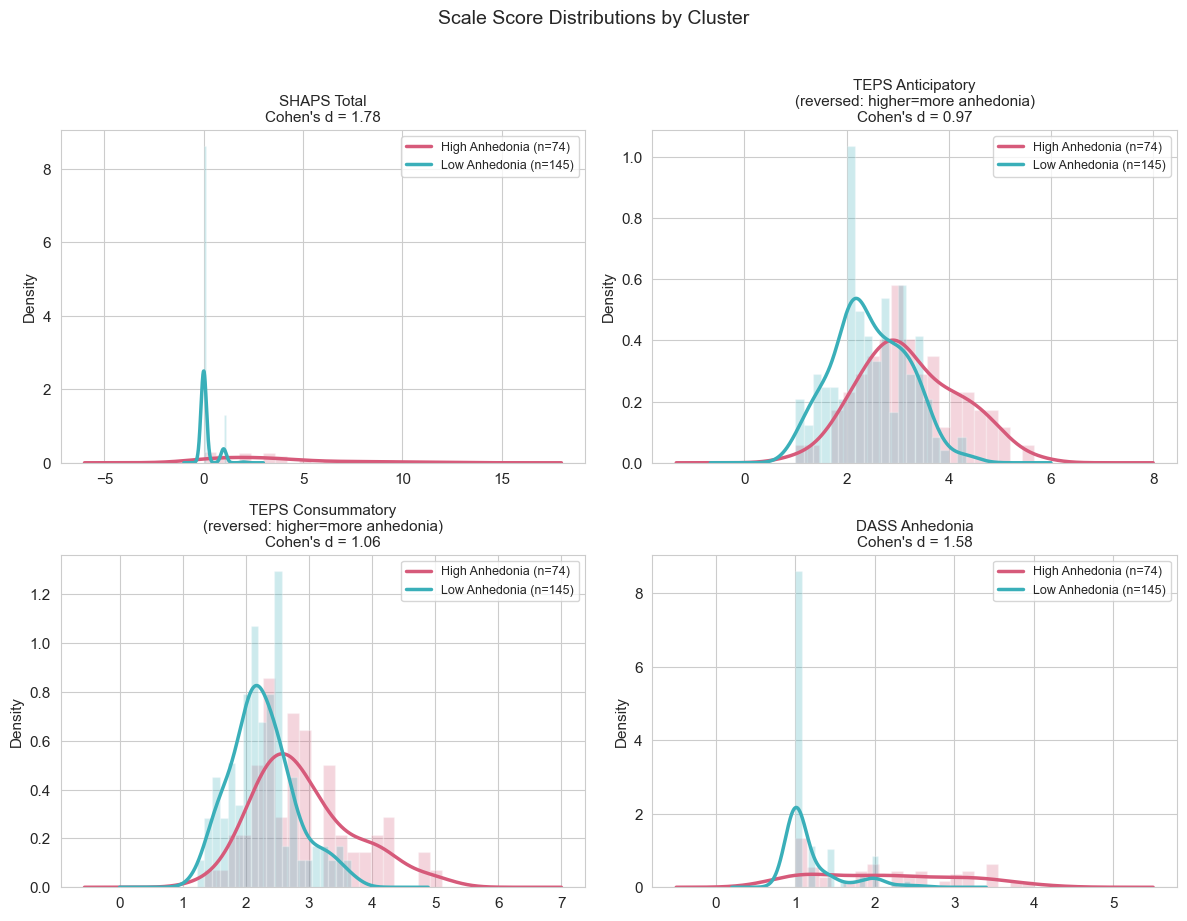

In [21]:
# =============================================================================
# 3c. KDE DISTRIBUTION OVERLAP PLOTS
# =============================================================================

scale_totals = {
    'SHAPS Total': 'SHAPS_total',
    'TEPS Anticipatory\n(reversed: higher=more anhedonia)': 'TEPS_ant_total',
    'TEPS Consummatory\n(reversed: higher=more anhedonia)': 'TEPS_con_total',
    'DASS Anhedonia': 'DASS_anh_total',
}

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

for ax, (title, col) in zip(axes, scale_totals.items()):
    for label, color in [('High Anhedonia', '#D65A7A'), ('Low Anhedonia', '#3AAFB9')]:
        data = factor_scores_df.loc[factor_scores_df['cluster_label'] == label, col]
        n = len(data)
        ax.hist(data, bins=20, alpha=0.25, color=color, density=True)
        data.plot.kde(ax=ax, color=color, linewidth=2.5, label=f'{label} (n={n})')
    
    # Cohen's d for this scale
    high = factor_scores_df.loc[factor_scores_df['gmm_cluster'] == 0, col]
    low = factor_scores_df.loc[factor_scores_df['gmm_cluster'] == 1, col]
    pooled_sd = np.sqrt(((len(high)-1)*high.std()**2 + (len(low)-1)*low.std()**2) / (len(high)+len(low)-2))
    d = (high.mean() - low.mean()) / pooled_sd if pooled_sd > 0 else 0
    
    ax.set_title(f'{title}\nCohen\'s d = {d:.2f}', fontsize=11)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Scale Score Distributions by Cluster', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('kde_overlap_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3d. Alluvial/Sankey Diagram: Cross-Method Cluster Agreement

Shows how participants flow between three different grouping methods:
1. **SHAPS cutoff** (SHAPS >= 3 vs < 3)
2. **SHAPS+TEPS GMM** clusters
3. **Polychoric 4-factor GMM** clusters

This directly visualizes how the multi-scale approach reclassifies participants that SHAPS alone cannot distinguish.

Subjects with all three groupings: 219

Cross-tabulation: SHAPS Cutoff vs 4-Factor GMM
4-Factor GMM  High  Low
SHAPS Cutoff           
High (≥3)       39    0
Low (<3)        35  145

Cross-tabulation: SHAPS+TEPS GMM vs 4-Factor GMM
4-Factor GMM    High  Low
SHAPS+TEPS GMM           
High              36    2
Low               38  143


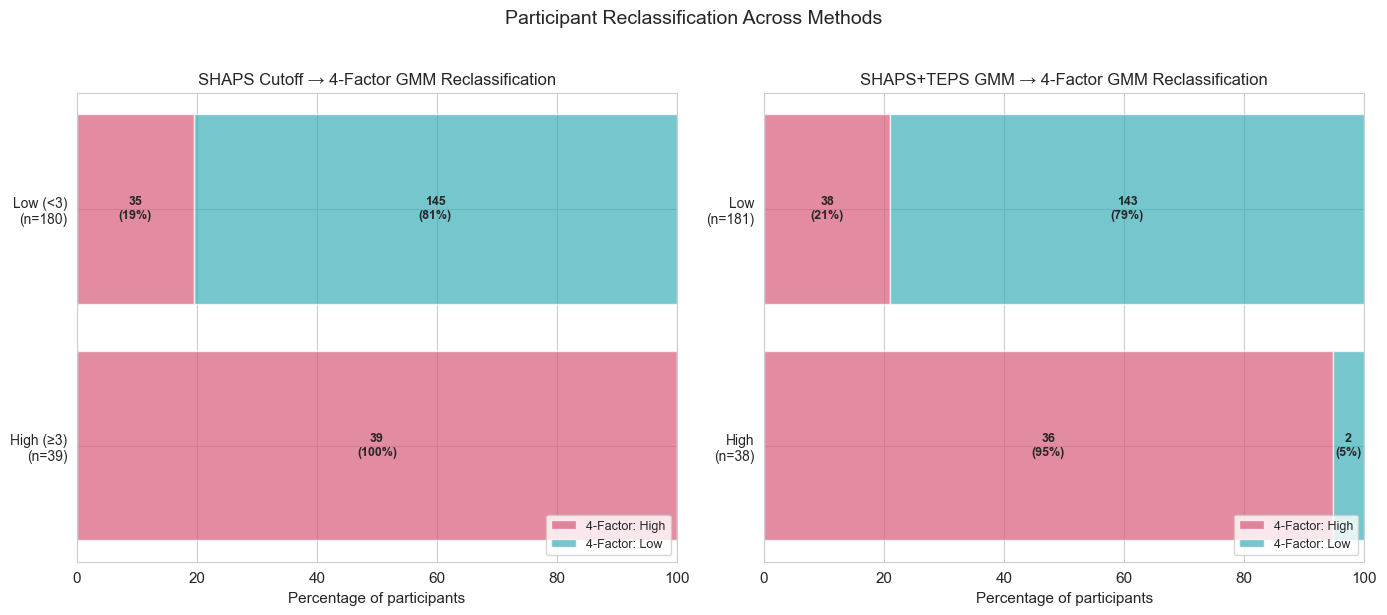


Agreement metrics:
  SHAPS cutoff vs 4-Factor GMM:   ARI = 0.437, NMI = 0.424
  SHAPS+TEPS GMM vs 4-Factor GMM: ARI = 0.373, NMI = 0.325


In [22]:
# =============================================================================
# 3d. ALLUVIAL / SANKEY DIAGRAM: CROSS-METHOD CLUSTER AGREEMENT
# =============================================================================

# Merge all three grouping methods on subjectkey
alluvial_df = shaps_cutoff[['subjectkey', 'group']].rename(columns={'group': 'SHAPS_cutoff'})
alluvial_df = alluvial_df.merge(
    shaps_clusters[['subjectkey', 'cluster']].rename(columns={'cluster': 'SHAPS_GMM'}),
    on='subjectkey', how='inner'
)
alluvial_df = alluvial_df.merge(
    poly_clusters[['subjectkey', 'gmm_cluster']].rename(columns={'gmm_cluster': 'Poly_GMM'}),
    on='subjectkey', how='inner'
)

# Create readable labels
alluvial_df['SHAPS Cutoff'] = alluvial_df['SHAPS_cutoff'].map({0: 'Low (<3)', 1: 'High (≥3)'})
alluvial_df['SHAPS+TEPS GMM'] = alluvial_df['SHAPS_GMM'].map({0: 'Low', 1: 'High'})
alluvial_df['4-Factor GMM'] = alluvial_df['Poly_GMM'].map({0: 'High', 1: 'Low'})

print(f"Subjects with all three groupings: {len(alluvial_df)}")
print(f"\nCross-tabulation: SHAPS Cutoff vs 4-Factor GMM")
ct1 = pd.crosstab(alluvial_df['SHAPS Cutoff'], alluvial_df['4-Factor GMM'])
print(ct1)

print(f"\nCross-tabulation: SHAPS+TEPS GMM vs 4-Factor GMM")
ct2 = pd.crosstab(alluvial_df['SHAPS+TEPS GMM'], alluvial_df['4-Factor GMM'])
print(ct2)

# --- Build Sankey-style visualization using matplotlib ---
# We'll use a grouped horizontal bar approach to show flow

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left panel: SHAPS cutoff -> 4-Factor GMM
methods = ['SHAPS Cutoff', '4-Factor GMM']
left_groups = alluvial_df.groupby(['SHAPS Cutoff', '4-Factor GMM']).size().reset_index(name='count')

# Stacked bars showing reclassification
for ax_idx, (source, target) in enumerate([
    ('SHAPS Cutoff', '4-Factor GMM'),
    ('SHAPS+TEPS GMM', '4-Factor GMM')
]):
    ax = axes[ax_idx]
    ct = pd.crosstab(alluvial_df[source], alluvial_df[target])
    
    # Normalize by source group to show proportions
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    
   
    colors_target = {'High': '#D65A7A', 'Low': '#3AAFB9'}
    
    bottom = np.zeros(len(ct_pct))
    for col in ct_pct.columns:
        bars = ax.barh(
            range(len(ct_pct)), ct_pct[col], 
            left=bottom, 
            color=colors_target[col], 
            alpha=0.7,
            edgecolor='white', linewidth=1
        )
        # Add count labels
        for i, (pct, cnt) in enumerate(zip(ct_pct[col], ct[col])):
            if pct > 5:
                ax.text(bottom[i] + pct/2, i, f'{cnt}\n({pct:.0f}%)', 
                       ha='center', va='center', fontsize=9, fontweight='bold')
        bottom += ct_pct[col].values
    
    ax.set_yticks(range(len(ct_pct)))
    ax.set_yticklabels([f'{idx}\n(n={ct.sum(axis=1)[idx]})' for idx in ct_pct.index], fontsize=10)
    ax.set_xlabel('Percentage of participants', fontsize=11)
    ax.set_title(f'{source} → 4-Factor GMM Reclassification', fontsize=12)
    ax.set_xlim(0, 100)
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=c, alpha=0.7, label=f'4-Factor: {l}') for l, c in colors_target.items()]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.suptitle('Participant Reclassification Across Methods', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('alluvial_reclassification.png', dpi=150, bbox_inches='tight')
plt.show()

# Adjusted Rand Index between methods
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari_shaps_poly = adjusted_rand_score(alluvial_df['SHAPS_cutoff'], alluvial_df['Poly_GMM'])
ari_gmm_poly = adjusted_rand_score(alluvial_df['SHAPS_GMM'], alluvial_df['Poly_GMM'])
nmi_shaps_poly = normalized_mutual_info_score(alluvial_df['SHAPS_cutoff'], alluvial_df['Poly_GMM'])
nmi_gmm_poly = normalized_mutual_info_score(alluvial_df['SHAPS_GMM'], alluvial_df['Poly_GMM'])

print(f"\nAgreement metrics:")
print(f"  SHAPS cutoff vs 4-Factor GMM:   ARI = {ari_shaps_poly:.3f}, NMI = {nmi_shaps_poly:.3f}")
print(f"  SHAPS+TEPS GMM vs 4-Factor GMM: ARI = {ari_gmm_poly:.3f}, NMI = {nmi_gmm_poly:.3f}")

---
## 5e. Bootstrap Stability of Cluster Assignments

For each of 500 bootstrap resamples, we refit a GMM (k=2) on the 4 polychoric factor scores and track how consistently each participant is assigned to the same cluster. Participants with stability > 0.80 are considered "stably classified."

This addresses the reviewer question: **"How robust are the individual cluster assignments?"**

In [26]:
# =============================================================================
# 5e. BOOTSTRAP STABILITY OF CLUSTER ASSIGNMENTS
# =============================================================================

n_boot = 500
rng = np.random.RandomState(42)
factor_matrix = factor_scores_df[factor_cols].values
n_subjects = len(factor_matrix)
original_labels = factor_scores_df['gmm_cluster'].values

# Track: for each participant, how many times assigned to cluster 0 (out of times sampled)
cluster0_counts = np.zeros(n_subjects)
sampled_counts = np.zeros(n_subjects)
boot_aris = []

print(f"Running {n_boot} bootstrap resamples...")
for b in range(n_boot):
    # Bootstrap resample (with replacement)
    boot_idx = rng.choice(n_subjects, size=n_subjects, replace=True)
    boot_data = factor_matrix[boot_idx]
    
    # Fit GMM on bootstrap sample
    gmm_boot = GaussianMixture(n_components=2, random_state=b)
    gmm_boot.fit(boot_data)
    
    # Predict on ALL original participants (not just bootstrapped)
    boot_labels = gmm_boot.predict(factor_matrix)
    
    # Resolve label alignment: match bootstrap labels to original labels
    # by checking which assignment gives higher ARI
    ari_direct = adjusted_rand_score(original_labels, boot_labels)
    ari_flipped = adjusted_rand_score(original_labels, 1 - boot_labels)
    
    if ari_flipped > ari_direct:
        boot_labels = 1 - boot_labels
        boot_aris.append(ari_flipped)
    else:
        boot_aris.append(ari_direct)
    
    # Track per-participant assignment
    cluster0_counts += (boot_labels == 0)
    sampled_counts += 1
    
    if (b + 1) % 100 == 0:
        print(f"  Bootstrap {b+1}/{n_boot} done (mean ARI so far: {np.mean(boot_aris):.3f})")

# Compute per-participant stability
# Stability = fraction of bootstraps where participant was assigned to SAME cluster as original
stability = np.where(
    original_labels == 0,
    cluster0_counts / sampled_counts,        # for cluster-0 participants: % assigned to cluster 0
    1 - cluster0_counts / sampled_counts     # for cluster-1 participants: % assigned to cluster 1
)

factor_scores_df['boot_stability'] = stability

print(f"\n{'='*60}")
print(f"BOOTSTRAP STABILITY RESULTS ({n_boot} resamples)")
print(f"{'='*60}")
print(f"  Mean ARI (bootstrap vs original):  {np.mean(boot_aris):.3f} ± {np.std(boot_aris):.3f}")
print(f"  Median ARI:                        {np.median(boot_aris):.3f}")
print(f"  Mean per-participant stability:     {np.mean(stability):.3f}")
print(f"  Participants with stability ≥ 0.80: {np.sum(stability >= 0.80)} / {n_subjects} ({100*np.mean(stability >= 0.80):.1f}%)")
print(f"  Participants with stability ≥ 0.90: {np.sum(stability >= 0.90)} / {n_subjects} ({100*np.mean(stability >= 0.90):.1f}%)")
print(f"  Participants with stability < 0.60: {np.sum(stability < 0.60)} / {n_subjects} ({100*np.mean(stability < 0.60):.1f}%)")

Running 500 bootstrap resamples...
  Bootstrap 100/500 done (mean ARI so far: 0.797)
  Bootstrap 200/500 done (mean ARI so far: 0.801)
  Bootstrap 300/500 done (mean ARI so far: 0.799)
  Bootstrap 400/500 done (mean ARI so far: 0.796)
  Bootstrap 500/500 done (mean ARI so far: 0.801)

BOOTSTRAP STABILITY RESULTS (500 resamples)
  Mean ARI (bootstrap vs original):  0.801 ± 0.187
  Median ARI:                        0.857
  Mean per-participant stability:     0.473
  Participants with stability ≥ 0.80: 0 / 219 (0.0%)
  Participants with stability ≥ 0.90: 0 / 219 (0.0%)
  Participants with stability < 0.60: 219 / 219 (100.0%)


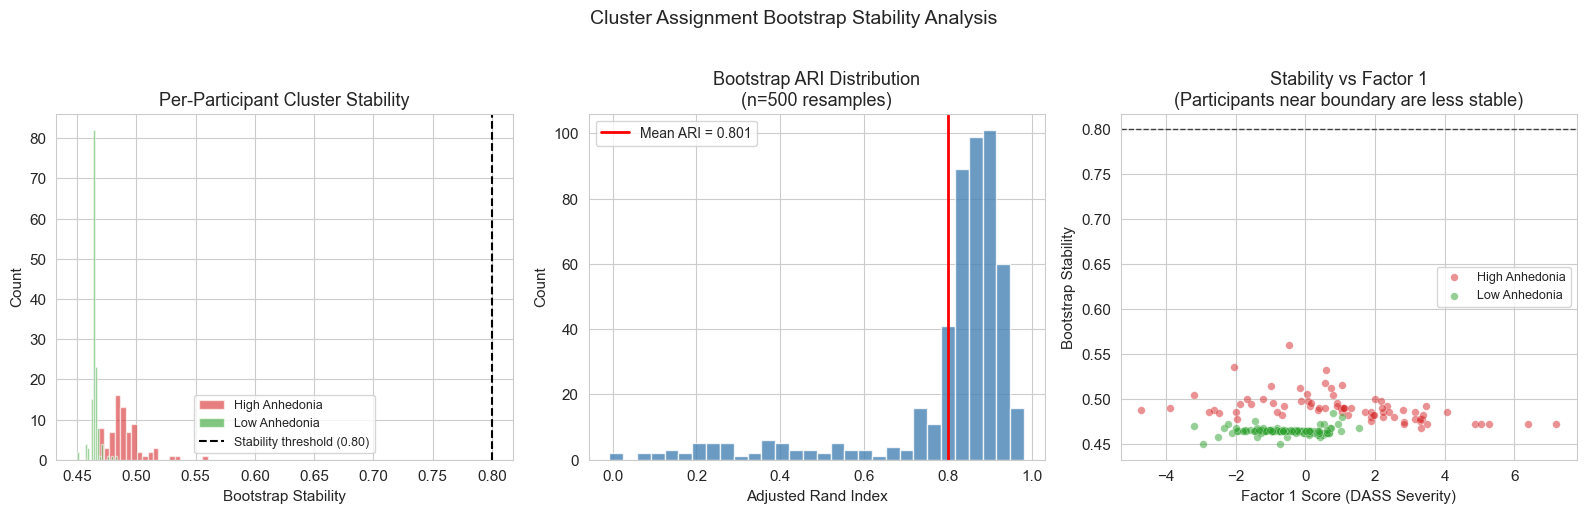

In [27]:
# =============================================================================
# 5e (cont). BOOTSTRAP STABILITY VISUALIZATIONS
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Histogram of per-participant stability
ax = axes[0]
for label, color in [('High Anhedonia', '#d62728'), ('Low Anhedonia', '#2ca02c')]:
    mask = factor_scores_df['cluster_label'] == label
    ax.hist(stability[mask], bins=20, alpha=0.6, color=color, label=label, edgecolor='white')
ax.axvline(x=0.80, color='black', linestyle='--', linewidth=1.5, label='Stability threshold (0.80)')
ax.set_xlabel('Bootstrap Stability')
ax.set_ylabel('Count')
ax.set_title('Per-Participant Cluster Stability')
ax.legend(fontsize=9)

# Panel 2: Histogram of bootstrap ARI values
ax = axes[1]
ax.hist(boot_aris, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(x=np.mean(boot_aris), color='red', linewidth=2, label=f'Mean ARI = {np.mean(boot_aris):.3f}')
ax.set_xlabel('Adjusted Rand Index')
ax.set_ylabel('Count')
ax.set_title(f'Bootstrap ARI Distribution\n(n={n_boot} resamples)')
ax.legend(fontsize=10)

# Panel 3: Stability vs Factor 1 score (the primary cluster driver)
ax = axes[2]
for label, color in [('High Anhedonia', '#d62728'), ('Low Anhedonia', '#2ca02c')]:
    mask = factor_scores_df['cluster_label'] == label
    ax.scatter(
        factor_scores_df.loc[mask, 'PolyFactor1'], 
        stability[mask],
        alpha=0.5, s=30, color=color, label=label, edgecolors='white', linewidths=0.3
    )
ax.axhline(y=0.80, color='black', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlabel('Factor 1 Score (DASS Severity)')
ax.set_ylabel('Bootstrap Stability')
ax.set_title('Stability vs Factor 1\n(Participants near boundary are less stable)')
ax.legend(fontsize=9)

plt.suptitle('Cluster Assignment Bootstrap Stability Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('bootstrap_stability.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5f. Permutation Test for Cluster Distinctness

We test whether the two clusters are significantly distinct in the multivariate factor score space using Hotelling's T² statistic. We permute cluster labels 1000 times to build a null distribution and compare to the observed T².

This directly addresses: **"Are these clusters real, or could they arise from noise?"**

Observed Hotelling's T² = 255.81
Equivalent F(4, 214) = 63.07, parametric p = 0.00e+00

Running 1000 permutations...

Permutation test results:
  Observed T² = 255.81
  Null distribution: mean = 4.08, max = 16.91
  Permutation p-value = 0.0000 (1000 permutations)
  (p < 0.0010 — observed T² exceeds all 1000 permutation values)


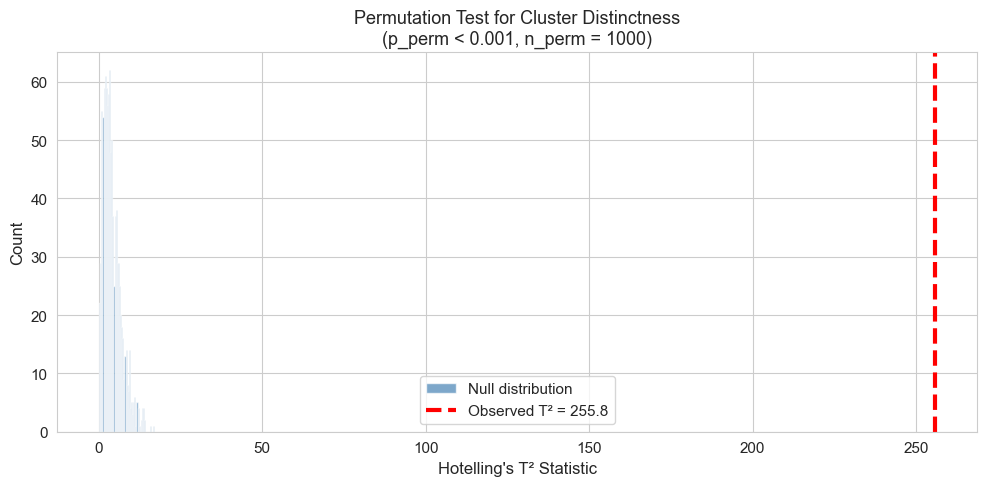


ALTERNATIVE CLUSTERING ROBUSTNESS CHECK

  Method                      Silhouette   ARI vs GMM
  --------------------------------------------------
  GMM (original)                   0.292            —
  k-Means                          0.268        0.063
  Ward Hierarchical                0.288        0.007

High ARI (>0.80) indicates the 2-cluster solution is algorithm-independent.


In [28]:
# =============================================================================
# 5f. PERMUTATION TEST FOR CLUSTER DISTINCTNESS (Hotelling's T²)
# =============================================================================

def hotellings_t2(X1, X2):
    """
    Compute Hotelling's T² statistic for two multivariate groups.
    T² = n1*n2/(n1+n2) * (mean1 - mean2)' * S_pooled_inv * (mean1 - mean2)
    """
    n1, p = X1.shape
    n2 = X2.shape[0]
    
    mean_diff = X1.mean(axis=0) - X2.mean(axis=0)
    
    # Pooled covariance matrix
    S1 = np.cov(X1, rowvar=False)
    S2 = np.cov(X2, rowvar=False)
    S_pooled = ((n1 - 1) * S1 + (n2 - 1) * S2) / (n1 + n2 - 2)
    
    # Invert with regularization for numerical stability
    S_pooled_inv = np.linalg.pinv(S_pooled)
    
    T2 = (n1 * n2 / (n1 + n2)) * mean_diff @ S_pooled_inv @ mean_diff
    return T2

# Observed T²
factor_matrix = factor_scores_df[factor_cols].values
labels = factor_scores_df['gmm_cluster'].values

X_high = factor_matrix[labels == 0]
X_low = factor_matrix[labels == 1]
T2_observed = hotellings_t2(X_high, X_low)

# Convert to F-statistic for interpretability
n1, n2, p = len(X_high), len(X_low), len(factor_cols)
F_observed = T2_observed * (n1 + n2 - p - 1) / ((n1 + n2 - 2) * p)
df1, df2 = p, n1 + n2 - p - 1
p_parametric = 1 - stats.f.cdf(F_observed, df1, df2)

print(f"Observed Hotelling's T² = {T2_observed:.2f}")
print(f"Equivalent F({df1}, {df2}) = {F_observed:.2f}, parametric p = {p_parametric:.2e}")

# --- Permutation null distribution ---
n_perm = 1000
rng = np.random.RandomState(42)
T2_null = np.zeros(n_perm)

print(f"\nRunning {n_perm} permutations...")
for i in range(n_perm):
    perm_labels = rng.permutation(labels)
    X1_perm = factor_matrix[perm_labels == 0]
    X2_perm = factor_matrix[perm_labels == 1]
    T2_null[i] = hotellings_t2(X1_perm, X2_perm)

# Permutation p-value
p_perm = np.mean(T2_null >= T2_observed)

print(f"\nPermutation test results:")
print(f"  Observed T² = {T2_observed:.2f}")
print(f"  Null distribution: mean = {np.mean(T2_null):.2f}, max = {np.max(T2_null):.2f}")
print(f"  Permutation p-value = {p_perm:.4f} ({n_perm} permutations)")
if p_perm == 0:
    print(f"  (p < {1/n_perm:.4f} — observed T² exceeds all {n_perm} permutation values)")

# --- Visualization ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(T2_null, bins=50, color='steelblue', alpha=0.7, edgecolor='white', label='Null distribution')
ax.axvline(x=T2_observed, color='red', linewidth=3, linestyle='--', 
           label=f'Observed T² = {T2_observed:.1f}')
ax.set_xlabel("Hotelling's T² Statistic", fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title(f"Permutation Test for Cluster Distinctness\n"
             f"(p_perm {'< ' + str(1/n_perm) if p_perm == 0 else '= ' + f'{p_perm:.4f}'}, "
             f"n_perm = {n_perm})", fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('permutation_test_cluster_distinctness.png', dpi=150, bbox_inches='tight')
plt.show()

# Also run with alternative clustering methods as robustness check
print("\n" + "="*60)
print("ALTERNATIVE CLUSTERING ROBUSTNESS CHECK")
print("="*60)

# k-Means
km = KMeans(n_clusters=2, random_state=42, n_init=10)
km_labels = km.fit_predict(factor_matrix)
ari_km = adjusted_rand_score(labels, km_labels)
sil_km = silhouette_score(factor_matrix, km_labels)

# Ward's hierarchical
ward = AgglomerativeClustering(n_clusters=2, linkage='ward')
ward_labels = ward.fit_predict(factor_matrix)
ari_ward = adjusted_rand_score(labels, ward_labels)
sil_ward = silhouette_score(factor_matrix, ward_labels)

# GMM silhouette
sil_gmm = silhouette_score(factor_matrix, labels)

print(f"\n  {'Method':<25} {'Silhouette':>12} {'ARI vs GMM':>12}")
print(f"  {'-'*50}")
print(f"  {'GMM (original)':<25} {sil_gmm:>12.3f} {'—':>12}")
print(f"  {'k-Means':<25} {sil_km:>12.3f} {ari_km:>12.3f}")
print(f"  {'Ward Hierarchical':<25} {sil_ward:>12.3f} {ari_ward:>12.3f}")
print(f"\nHigh ARI (>0.80) indicates the 2-cluster solution is algorithm-independent.")

---
## Summary of Additional Analyses

| Analysis | Section | Key Output |
|----------|---------|------------|
| Factor loading table (publication quality) | 1a | TABLE 1: 37 items × 4 factors with communalities |
| Ordinal alpha reliability | 1b | TABLE 2: Scale and factor reliability (ordinal vs Cronbach) |
| Polychoric correlation heatmap | 1c | Block-diagonal structure visualization |
| MTMM convergent/discriminant validity | 2a | Anhedonia converges with depression, diverges from anxiety |
| Radar plot of cluster profiles | 3a | Visual cluster phenotype comparison |
| Factor score pairplot | 3b | Pairwise cluster separation by factor |
| KDE distribution overlap | 3c | Per-scale distribution overlap with Cohen's d |
| Cross-method reclassification | 3d | Alluvial flow + ARI between methods |
| External clinical validation | 4a | TABLE 3: Mann-Whitney U with FDR on 18 external measures |
| SHAPS-only vs multi-scale comparison | 5a | TABLE 4: Entropy, harmonic N, effect sizes by method |
| Bootstrap cluster stability | 5e | Per-participant stability, ARI distribution |
| Permutation test (Hotelling's T²) | 5f | Multivariate cluster distinctness p-value |
| Alternative clustering robustness | 5f | k-Means and Ward's ARI agreement with GMM |